In [1]:
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType,StructField,StringType,IntegerType,DoubleType

spark = (SparkSession.builder
         .appName("check-python")
         .master("local[*]")
         .config("spark.pyspark.python", sys.executable)
         .config("spark.pyspark.driver.python", sys.executable)
         .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/26 09:49:14 WARN Utils: Your hostname, MacBook--Azich.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.2 instead (on interface en0)
26/02/26 09:49:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/26 09:49:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/26 09:49:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


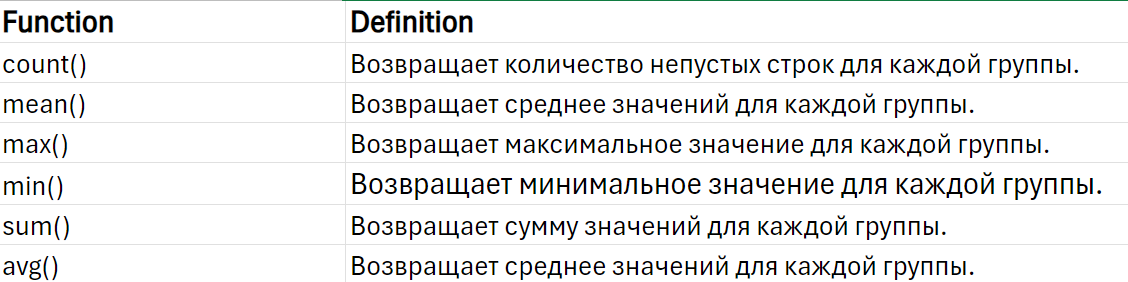

Когда мы выполняем groupBy() для PySpark Dataframe, он возвращает объект GroupedData, к которому могут быть применены следующие основные агрегатные функции.

In [ ]:
simpleData = [("James","Sales","NY",90000,34,10000),
    ("Michael","Sales","NY",86000,56,20000),
    ("Robert","Sales","CA",81000,30,23000),
    ("Maria","Finance","CA",90000,24,23000),
    ("Raman","Finance","CA",99000,40,24000),
    ("Scott","Finance","NY",83000,36,19000),
    ("Jen","Finance","NY",79000,53,15000),
    ("Jeff","Marketing","CA",80000,25,18000),
    ("Kumar","Marketing","NY",91000,50,21000)
  ]

schema = ["employee_name","department","state","salary","age","bonus"]
df = spark.createDataFrame(data=simpleData, schema = schema)
df.printSchema()
df.show(truncate=False)

In [2]:
df = [('James','Sales','NY',90000,34,10000),
    ("Michael","Sales","NY",86000,56,20000),
    ("Robert","Sales","CA",81000,30,23000),
    ("Maria","Finance","CA",90000,24,23000),
    ("Raman","Finance","CA",99000,40,24000),
    ("Scott","Finance","NY",83000,36,19000),
    ("Jen","Finance","NY",79000,53,15000),
    ("Jeff","Marketing","CA",80000,25,18000),
    ("Kumar","Marketing","NY",91000,50,21000)
]
schema = ['employee_name','department','state','salary','age','bonus']
df = spark.createDataFrame(data=df, schema=schema)
df.printSchema()
df.show(truncate=False)

root
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- state: string (nullable = true)
 |-- salary: long (nullable = true)
 |-- age: long (nullable = true)
 |-- bonus: long (nullable = true)



+-------------+----------+-----+------+---+-----+
|employee_name|department|state|salary|age|bonus|
+-------------+----------+-----+------+---+-----+
|James        |Sales     |NY   |90000 |34 |10000|
|Michael      |Sales     |NY   |86000 |56 |20000|
|Robert       |Sales     |CA   |81000 |30 |23000|
|Maria        |Finance   |CA   |90000 |24 |23000|
|Raman        |Finance   |CA   |99000 |40 |24000|
|Scott        |Finance   |NY   |83000 |36 |19000|
|Jen          |Finance   |NY   |79000 |53 |15000|
|Jeff         |Marketing |CA   |80000 |25 |18000|
|Kumar        |Marketing |NY   |91000 |50 |21000|
+-------------+----------+-----+------+---+-----+



Мы будем использовать этот PySpark DataFrame для выполнения функции groupBy() по столбцу “department” и вычисления таких агрегатов, как минимальная, максимальная, средняя и суммарная зарплата для каждой группы, используя агрегатные функции min(), max() и sum() соответственно.

Вот как работает функция groupBy():

Группировка: Вы указываете один или несколько столбцов в функции groupBy(), чтобы определить критерии группировки. Строки с одинаковыми значениями в указанных столбцах объединяются в отдельные группы.

Агрегация: После группировки строк к каждой группе можно применить агрегатные функции, такие как COUNT, SUM, AVG, MIN, MAX и т. д. Эти агрегатные функции вычисляют сводную статистику для строк в каждой группе.

In [3]:
df.groupBy("department").sum("salary").show(truncate=False)

+----------+-----------+
|department|sum(salary)|
+----------+-----------+
|Sales     |257000     |
|Finance   |351000     |
|Marketing |171000     |
+----------+-----------+



In [4]:
df.groupBy("department").count().show(truncate=False)

+----------+-----+
|department|count|
+----------+-----+
|Sales     |3    |
|Finance   |4    |
|Marketing |2    |
+----------+-----+



In [6]:
# Группировка и агрегация нескольких столбцов

df.groupBy("department","state") \
    .sum("salary","bonus") \
    .show(truncate=False)

+----------+-----+-----------+----------+
|department|state|sum(salary)|sum(bonus)|
+----------+-----+-----------+----------+
|Sales     |NY   |176000     |30000     |
|Sales     |CA   |81000      |23000     |
|Finance   |CA   |189000     |47000     |
|Finance   |NY   |162000     |34000     |
|Marketing |NY   |91000      |21000     |
|Marketing |CA   |80000      |18000     |
+----------+-----+-----------+----------+



В качестве альтернативы можно использовать groupBy().agg() для выполнения агрегирования столбцов DataFrame после их группировки по одному или нескольким ключам. 

Это позволяет вычислять агрегатные функции для сгруппированных данных, генерируя сводную статистику для каждой группы.

После группировки вы вызываете метод agg(), который принимает одну или несколько пар имен столбцов и агрегатных функций. 

Функции агрегирования могут включать встроенные функции, такие как count(), sum(), avg(), min(), max() и т. д., а также функции, определяемые пользователем (UDF).

•	groupBy().agg() → всегда, если нужна агрегация по нескольким метрикам

•	groupBy().count() → когда нужна ровно одна метрика


In [12]:
# Выполнение нескольких агрегаций за один раз

df.groupBy("department", 'state') \
    .agg(F.sum("salary").alias("sum_salary"), \
         F.avg("salary").alias("avg_salary"), \
         F.sum("bonus").alias("sum_bonus"), \
         F.max("bonus").alias("max_bonus") \
     ) \
    .show(truncate=False)

+----------+-----+----------+----------+---------+---------+
|department|state|sum_salary|avg_salary|sum_bonus|max_bonus|
+----------+-----+----------+----------+---------+---------+
|Sales     |NY   |176000    |88000.0   |30000    |20000    |
|Sales     |CA   |81000     |81000.0   |23000    |23000    |
|Finance   |CA   |189000    |94500.0   |47000    |24000    |
|Finance   |NY   |162000    |81000.0   |34000    |19000    |
|Marketing |NY   |91000     |91000.0   |21000    |21000    |
|Marketing |CA   |80000     |80000.0   |18000    |18000    |
+----------+-----+----------+----------+---------+---------+



Также есть возможность использовать функцию where():

In [ ]:
# Using filter on aggregate data

df.groupBy('department').agg(
    F.sum('salary').alias('sum_salary'),
    F.avg('salary').alias('avg_salary'),
    F.sum('bonus').alias('sum_bonus'),
    F.max('bonus').alias('max_bonus')
).where(F.col('sum_bonus') >= 50000).show(truncate=False)

+----------+----------+-----------------+---------+---------+
|department|sum_salary|avg_salary       |sum_bonus|max_bonus|
+----------+----------+-----------------+---------+---------+
|Sales     |257000    |85666.66666666667|53000    |23000    |
|Finance   |351000    |87750.0          |81000    |24000    |
+----------+----------+-----------------+---------+---------+



In [15]:
spark.stop()